# House Prices Project

**Dataset**: [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)

**Goal**: Predict the sale price of houses using statistical and machine learning methods.


---
## Setup and Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add your additional imports as needed
from sklearn import preprocessing
import statsmodels.api as sm
import torch

pd.set_option('display.max_columns', 100)
%matplotlib inline

ModuleNotFoundError: No module named 'sklearn'

# Setting the directory for data

In [ ]:
dir("/Users/ljunodrstat/CStat2026_project/")
os.listdir()

---
## Load Data

In [4]:
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')

print(f'Training set: {train.shape[0]} rows, {train.shape[1]} columns')
print(f'Test set: {test.shape[0]} rows, {test.shape[1]} columns')

train.head()

Training set: 1460 rows, 81 columns
Test set: 1459 rows, 80 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Cleaning the data
NA Values : Is there any NAs values in the variables of intersts for the project ? If any, how to replace them
Missing values ? 

In [5]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
features_dt = pd.DataFrame(train[features])
features_dt.head()

,OverallQual,ExterQual,BsmtQual,KitchenQual,FireplaceQu,CentralAir,LotShape,LandSlope,MoSold,YrSold
0,7,Gd,Gd,Gd,NaN,Y,Reg,Gtl,2,2008
1,6,TA,Gd,TA,TA,Y,Reg,Gtl,5,2007
2,7,Gd,Gd,Gd,TA,Y,IR1,Gtl,9,2008
3,7,TA,TA,Gd,Gd,Y,IR1,Gtl,2,2006
4,8,Gd,Gd,Gd,TA,Y,IR1,Gtl,12,2008


In [6]:
na_dt = features_dt[features_dt.isna().any(axis=1)]
na_dt.shape

(699, 10)

In [7]:
for col in na_dt.columns:
    na_dt[col].unique()
    print(f"levels of variables {col} : {na_dt[col].unique()}")

levels of variables OverallQual : [7 5 4 8 6 3 9 1 2]
levels of variables ExterQual : ['Gd' 'TA' 'Fa' 'Ex']
levels of variables BsmtQual : ['Gd' 'TA' nan 'Ex' 'Fa']
levels of variables KitchenQual : ['Gd' 'TA' 'Fa' 'Ex']
levels of variables FireplaceQu : [nan 'Gd' 'Ex' 'Po' 'TA']
levels of variables CentralAir : ['Y' 'N']
levels of variables LotShape : ['Reg' 'IR1' 'IR2' 'IR3']
levels of variables LandSlope : ['Gtl' 'Mod' 'Sev']
levels of variables MoSold : [ 2 10  9  7  6  5  1 12  8  3  4 11]
levels of variables YrSold : [2008 2009 2007 2006 2010]


# Nan Values 
We observe nan values in two variables : BsmtQual and FireplaceQu, which means "none" according to the description file of the Data. 
## Solution
We replace them with None for clarity purpose.
# Ordinal Values
6 variables (ExterQual, BsmtQual, KitchenQual, FireplaceQu, LotShape, LandSlope) are ordinal values, ranking a quality in differents rank (4 ranks in general, 3 for the LandSlope)
## Solution
Outside of OverallQual, which is numeric of type string, we need to correct them by adding a rank, by using a dictionnary. 

# NAN values

In [8]:
features_dt['BsmtQual'] = features_dt['BsmtQual'].replace('nan', 'No_Basement')

features_dt['FireplaceQu'] = features_dt['FireplaceQu'].replace('nan', 'No_Fireplace')
features_dt
features_dt['FireplaceQu'].unique()
features_dt['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

## Dictionnaries

In [9]:
qual_dict = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0,
    'No_basement': 0,
    'No_Fireplace': 0,
    'No_Kitchen': 0
}
slope_dict = {
    'Gtl': 3,
    'Mod': 2,
    'Sev': 1,   
    'NA': 0}
lotshape_dict = {
    'Reg': 4,
    'IR1': 3,
    'IR2': 2,
    'IR3': 1,
    'NA': 0}

features_dt['ExterQual'] = features_dt['ExterQual'].map(qual_dict)
features_dt['BsmtQual'] = features_dt['BsmtQual'].map(qual_dict)
features_dt['KitchenQual'] = features_dt['KitchenQual'].map(qual_dict)
features_dt['FireplaceQu'] = features_dt['FireplaceQu'].map(qual_dict)

features_dt['LotShape'] = features_dt['LotShape'].map(lotshape_dict)
features_dt['LandSlope'] = features_dt['LandSlope'].map(slope_dict)


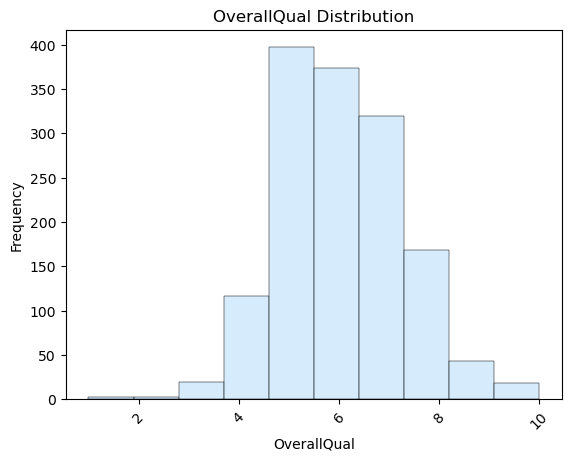

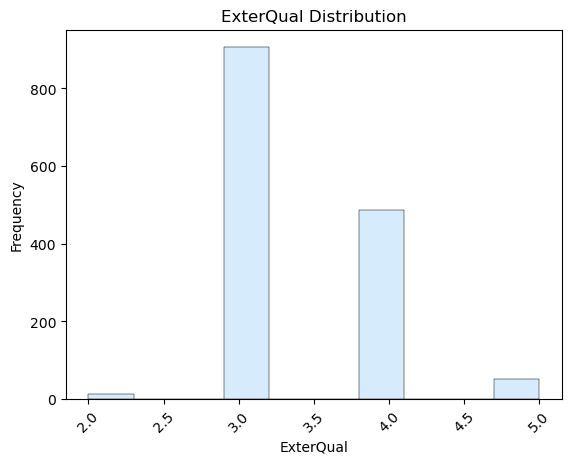

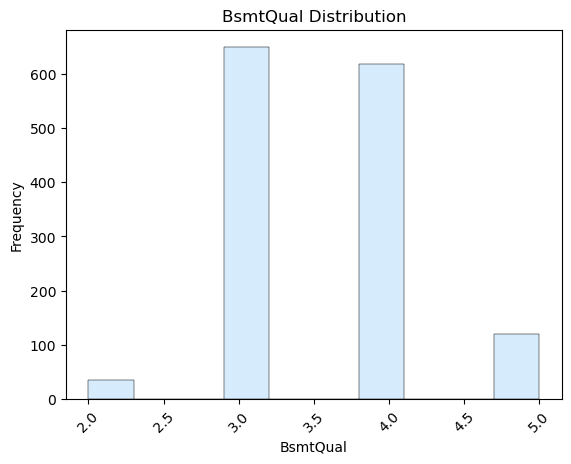

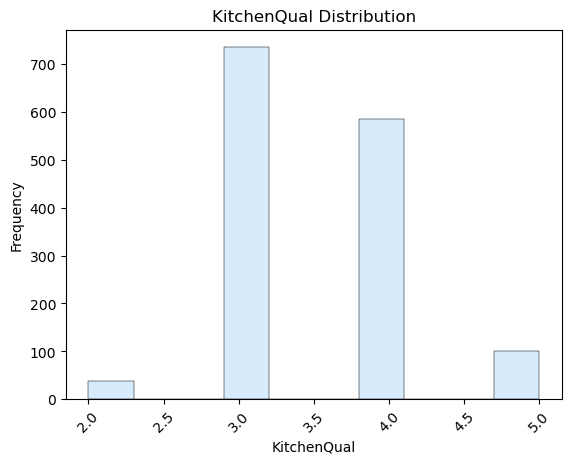

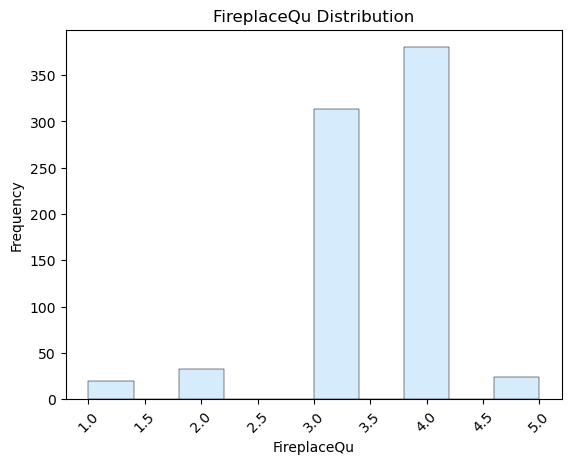

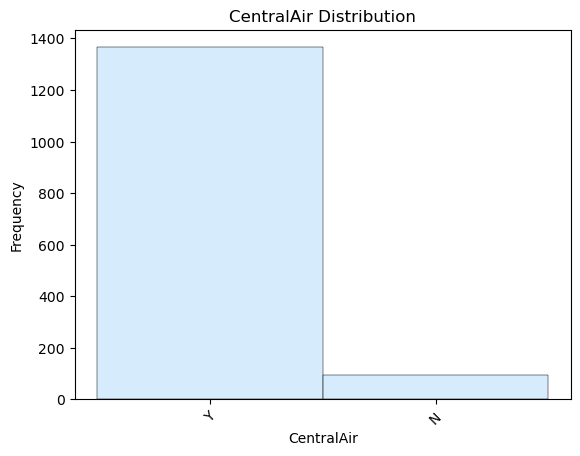

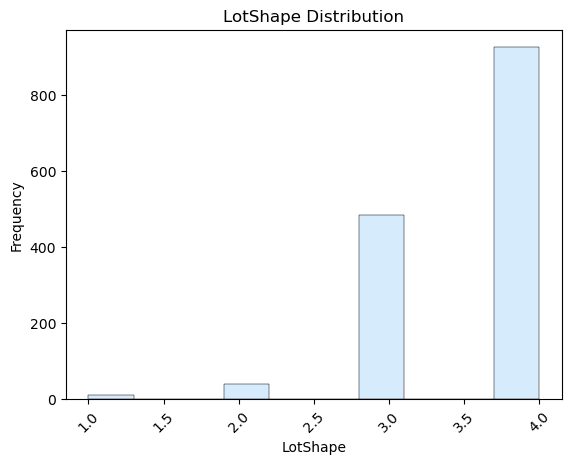

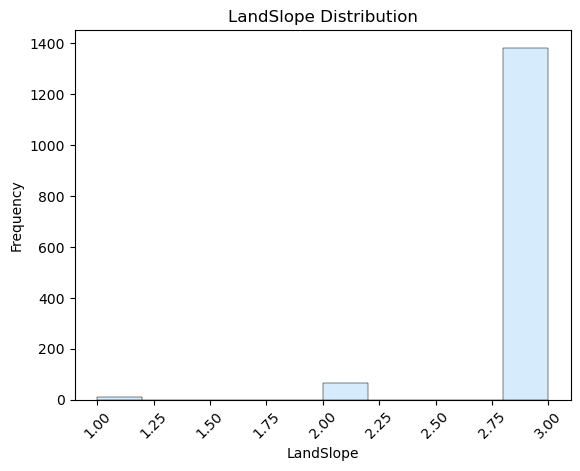

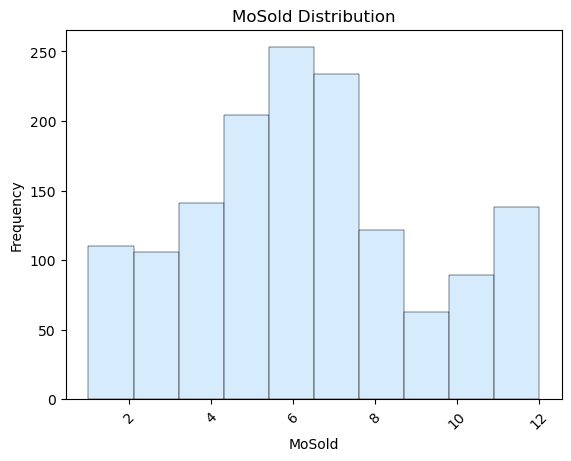

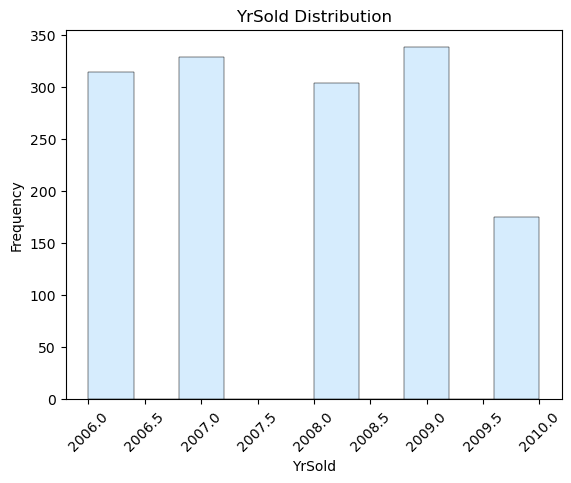

In [10]:

for col in features_dt.columns:
    sns.histplot(features_dt[col], kde=False, bins=10, color='#c9e6fd', edgecolor='black', linewidth=0.35)
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

The corrections give favorable results, we apply them to the train dataframe

In [11]:
train['ExterQual'] = train['ExterQual'].map(qual_dict)
train['BsmtQual'] = train['BsmtQual'].map(qual_dict)
train['KitchenQual'] = train['KitchenQual'].map(qual_dict)
train['FireplaceQu'] = train['FireplaceQu'].map(qual_dict)

train['LotShape'] = train['LotShape'].map(lotshape_dict)
train['LandSlope'] = train['LandSlope'].map(slope_dict)

train['BsmtQual'] = train['BsmtQual'].replace('nan', 'No_Basement')

train['FireplaceQu'] = train['FireplaceQu'].replace('nan', 'No_Fireplace')

<Axes: xlabel='LotShape', ylabel='Count'>

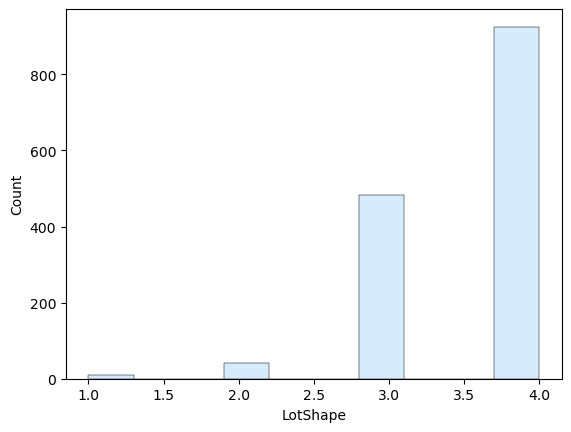

In [12]:
sns.histplot(train['LotShape'], kde=False, bins=10, color='#c9e6fd', edgecolor='black', linewidth=0.35)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


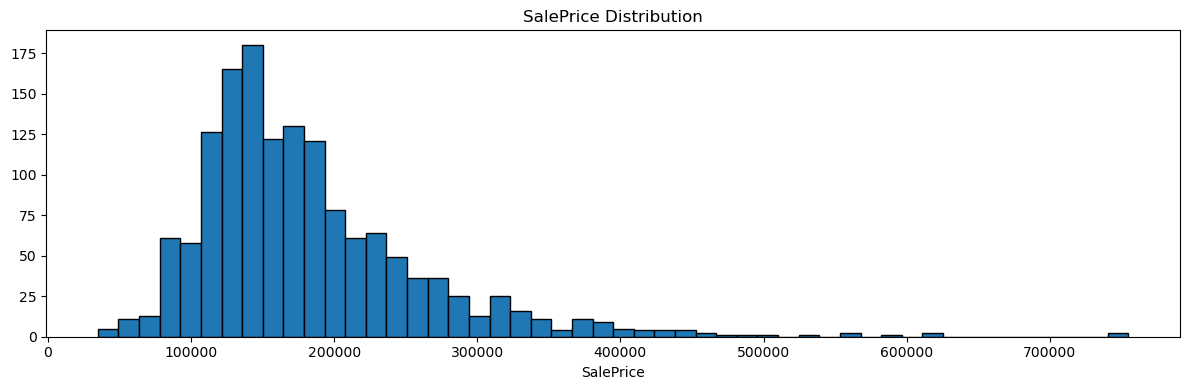

Skewness: 1.883


In [13]:
# Explore the target variable
print(train['SalePrice'].describe())

fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(train['SalePrice'], bins=50, edgecolor='black')
axes.set_title('SalePrice Distribution')
axes.set_xlabel('SalePrice')
plt.tight_layout()
plt.show()

print(f'Skewness: {train["SalePrice"].skew():.3f}')

The data is heavily skewed, what kind of transformation can we apply to make it more normal? 

A log transformation can bring a normal distribution

---
## Part 1: Classical Statistical Inference



Apply basic statistical methods to explore the data:
- **Sample mean and variance** of `SalePrice` and key features
- **Confidence intervals** for the mean SalePrice
- **Hypothesis testing** — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?
- Visualize distributions and support your conclusions with plots

Sample Mean and Variance of SalePrice and key features


In [16]:
train['LogSalePrice'] = np.log(train['SalePrice'])

mean_LogSalePrice = train['LogSalePrice'].mean()
median_LogSalePrice = train['LogSalePrice'].median()
std_LogSalePrice = train['LogSalePrice'].std()
print(f'Mean: {mean_LogSalePrice:.2f}')
print(f'Median: {median_LogSalePrice:.2f}')
print(f'Standard Deviation: {std_LogSalePrice:.2f}')

Mean: 12.02
Median: 12.00
Standard Deviation: 0.40


In [17]:
mean_SalePrice = train['SalePrice'].mean()
median_SalePrice = train['SalePrice'].median()
std_SalePrice = train['SalePrice'].std()
print(f'Mean: {mean_SalePrice:.2f}')
print(f'Median: {median_SalePrice:.2f}')
print(f'Standard Deviation: {std_SalePrice:.2f}')



Mean: 180921.20
Median: 163000.00
Standard Deviation: 79442.50


# Classement des features selon leur type

In [14]:
ordinal_mappings = {
    'ExterQual' : qual_dict,
    'BsmtQual' : qual_dict,
    'KitchenQual' : qual_dict,
    'FireplaceQu' : qual_dict,
    'LotShape' : lotshape_dict,
    'LandSlope' : slope_dict
}


def describe_features(df, feature, ordinal_mappings=None):
    if ordinal_mappings:
        mapped = df[feature].map(ordinal_mappings)
        valid = mapped.dropna()

        print(f"\n{feature} (ordinal ):")
        print(f"  Uniques values : {df[feature].unique()}")
        print(f" Distribution:\n{valid.value_counts().sort_index()}")
        print(f"  Mean: {valid.mean():.2f}, Median: {valid.median():.2f}, Std Dev: {valid.std():.2f}")
        print(f" Min-Max : {valid.min()} - {valid.max()}")
        print(f" Missing values: {df[feature].isna().sum()}")
    elif pd.api.types.is_numeric_dtype(df[feature]):
        valid = df[feature].dropna()
        print(f"\n{feature} (numerical):")
        print(f" Mean : {valid.mean():.2f}, Median: {valid.median():.2f}, Std Dev: {valid.std():.2f}")
        print(f" Min-Max : {valid.min()} - {valid.max()}")
        print(f" Q1 : {valid.quantile(0.25)}, Q3: {valid.quantile(0.75)}")
        print(f" Missing values: {df[feature].isna().sum()}")
    else: 
        print(f"\n{feature} (categorical):")
        print(f" Unique values: {df[feature].unique()}")
        print(f" Top values :\n {df[feature].nunique()}")
        print(f" Missing values: {df[feature].isna().sum()}")
    
    


In [15]:
features_ordinal = train[['ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 'LotShape', 'LandSlope']]
features_numerical = train[['SalePrice', 'OverallQual', 'MoSold', 'YrSold']]


In [16]:
print("==== Target : Numerical variables =====")
for feat in features_numerical.columns:
    describe_features(train, feat)



==== Target : Numerical variables =====

SalePrice (numerical):
 Mean : 180921.20, Median: 163000.00, Std Dev: 79442.50
 Min-Max : 34900 - 755000
 Q1 : 129975.0, Q3: 214000.0
 Missing values: 0

OverallQual (numerical):
 Mean : 6.10, Median: 6.00, Std Dev: 1.38
 Min-Max : 1 - 10
 Q1 : 5.0, Q3: 7.0
 Missing values: 0

MoSold (numerical):
 Mean : 6.32, Median: 6.00, Std Dev: 2.70
 Min-Max : 1 - 12
 Q1 : 5.0, Q3: 8.0
 Missing values: 0

YrSold (numerical):
 Mean : 2007.82, Median: 2008.00, Std Dev: 1.33
 Min-Max : 2006 - 2010
 Q1 : 2007.0, Q3: 2009.0
 Missing values: 0


In [17]:
features_ordinal.head()

,ExterQual,BsmtQual,KitchenQual,FireplaceQu,LotShape,LandSlope
0,4,4.0,4,NaN,4,3
1,3,4.0,3,3.0,4,3
2,4,4.0,4,3.0,3,3
3,3,3.0,4,4.0,3,3
4,4,4.0,4,3.0,3,3


In [18]:
print("\n=== Ordinal features ==== ")
for feat in features_ordinal.columns:
        describe_features(train, feat)


=== Ordinal features ==== 

ExterQual (numerical):
 Mean : 3.40, Median: 3.00, Std Dev: 0.57
 Min-Max : 2 - 5
 Q1 : 3.0, Q3: 4.0
 Missing values: 0

BsmtQual (numerical):
 Mean : 3.58, Median: 4.00, Std Dev: 0.68
 Min-Max : 2.0 - 5.0
 Q1 : 3.0, Q3: 4.0
 Missing values: 37

KitchenQual (numerical):
 Mean : 3.51, Median: 3.00, Std Dev: 0.66
 Min-Max : 2 - 5
 Q1 : 3.0, Q3: 4.0
 Missing values: 0

FireplaceQu (numerical):
 Mean : 3.46, Median: 4.00, Std Dev: 0.74
 Min-Max : 1.0 - 5.0
 Q1 : 3.0, Q3: 4.0
 Missing values: 690

LotShape (numerical):
 Mean : 3.59, Median: 4.00, Std Dev: 0.58
 Min-Max : 1 - 4
 Q1 : 3.0, Q3: 4.0
 Missing values: 0

LandSlope (numerical):
 Mean : 2.94, Median: 3.00, Std Dev: 0.28
 Min-Max : 1 - 3
 Q1 : 3.0, Q3: 3.0
 Missing values: 0


## Confidence intervals 
### for the mean SalePrice

In [19]:
mean_SalePrice = train['SalePrice'].mean()
std_SalePrice = train['SalePrice'].std()
n = len(train)
stat_err = stats.sem(train['SalePrice'], nan_policy='omit')
confidence = 0.95
degrees_freedom = n - 1
confidence_interval = stats.t.interval(confidence, degrees_freedom, loc=mean_SalePrice, scale=stat_err)

print(f"95% Confidence Interval for SalePrice: {confidence_interval[0]:.2f} to {confidence_interval[1]:.2f}")

95% Confidence Interval for SalePrice: 176842.84 to 184999.55


In [20]:

mean_LogSalePrice = train['LogSalePrice'].mean()
std_LogSalePrice = train['LogSalePrice'].std()
n_log = len(train)
stat_err_log = stats.sem(train['LogSalePrice'], nan_policy='omit')
confidence = 0.95
degrees_freedom = n_log - 1
confidence_interval_log = stats.t.interval(confidence, degrees_freedom, loc=mean_LogSalePrice, scale=stat_err_log)

print(f"95% Confidence Interval for LogSalePrice: {confidence_interval_log[0]:.2f} to {confidence_interval_log[1]:.2f}")

95% Confidence Interval for LogSalePrice: 12.00 to 12.04


<Axes: xlabel='LogSalePrice', ylabel='Count'>

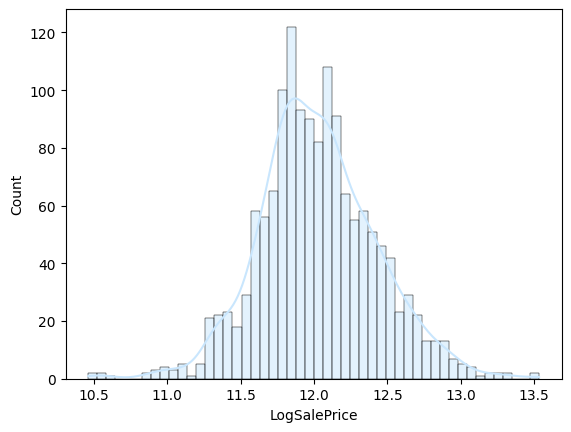

In [21]:

sns.histplot(train['LogSalePrice'], kde=True, bins=50, color='#c9e6fd', edgecolor='black', linewidth=0.35)

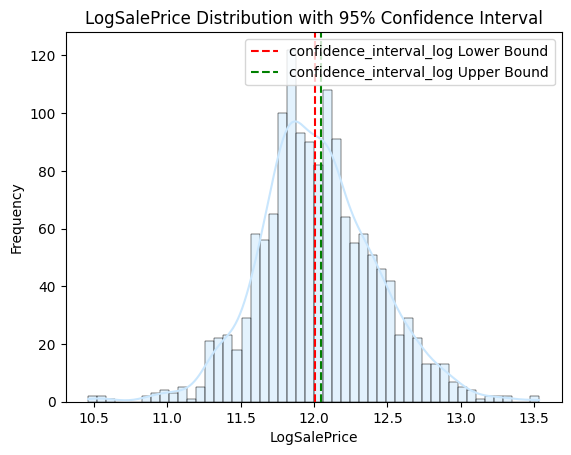

In [22]:

sns.histplot(train['LogSalePrice'], kde=True, bins=50, color='#c9e6fd', edgecolor='black', linewidth=0.35)
plt.axvline(confidence_interval_log[0], color='red', linestyle='--', label='confidence_interval_log Lower Bound')
plt.axvline(confidence_interval_log[1], color='green', linestyle='--', label='confidence_interval_log Upper Bound')
plt.title('LogSalePrice Distribution with 95% Confidence Interval')
plt.xlabel('LogSalePrice')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Hypothesis testing
 — e.g. is the mean SalePrice significantly different from \$180,000? Is the distribution of the transformed `SalePrice` normal (Shapiro-Wilk)?

In [23]:
hypothetisis_value = 180000
hypothetisis_value_log = np.log(hypothetisis_value)
t_statistic, p_value = stats.ttest_1samp(train['LogSalePrice'], popmean=hypothetisis_value_log, nan_policy='omit')
print(f"T-statistic: {t_statistic:.3f}, P-value: {p_value:.3f}")

T-statistic: -7.333, P-value: 0.000


In [24]:
shapiro_stat, shapiro_p = stats.shapiro(train['LogSalePrice'].dropna())
print(f"Shapiro-Wilk Test: Statistic={shapiro_stat:.3f}, P-value={shapiro_p:.3f}")

Shapiro-Wilk Test: Statistic=0.991, P-value=0.000


Skewness after log transformation: 0.121


<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_49136/1451824775.py:14: SyntaxWarning: invalid escape sequence '\m'
  axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_49136/1451824775.py:14: SyntaxWarning: invalid escape sequence '\s'
  axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')


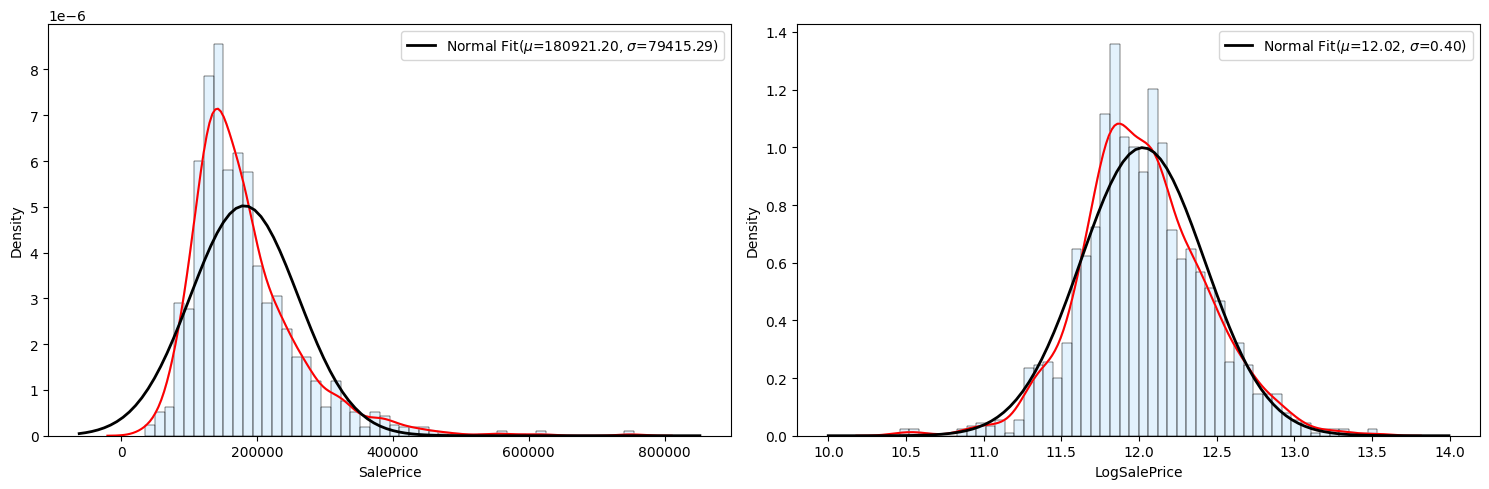

In [25]:
from scipy import stats
train['LogSalePrice'] = np.log(train['SalePrice'])
print(f'Skewness after log transformation: {train["LogSalePrice"].skew():.3f}')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cols = ['SalePrice', 'LogSalePrice']
for i, col in enumerate(cols):
    sns.histplot(train[col], bins=50, ax=axes[i],
                stat='density', kde=True, color='#c9e6fd', edgecolor='black', linewidth=0.35)
    sns.kdeplot(train[col], ax=axes[i], color='red', linewidth=1.5)
    mu, std = stats.norm.fit(train[col])
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'k', linewidth=2, label=f'Normal Fit($\mu$={mu:.2f}, $\sigma$={std:.2f})')
    axes[i].legend()
plt.tight_layout()
plt.show()

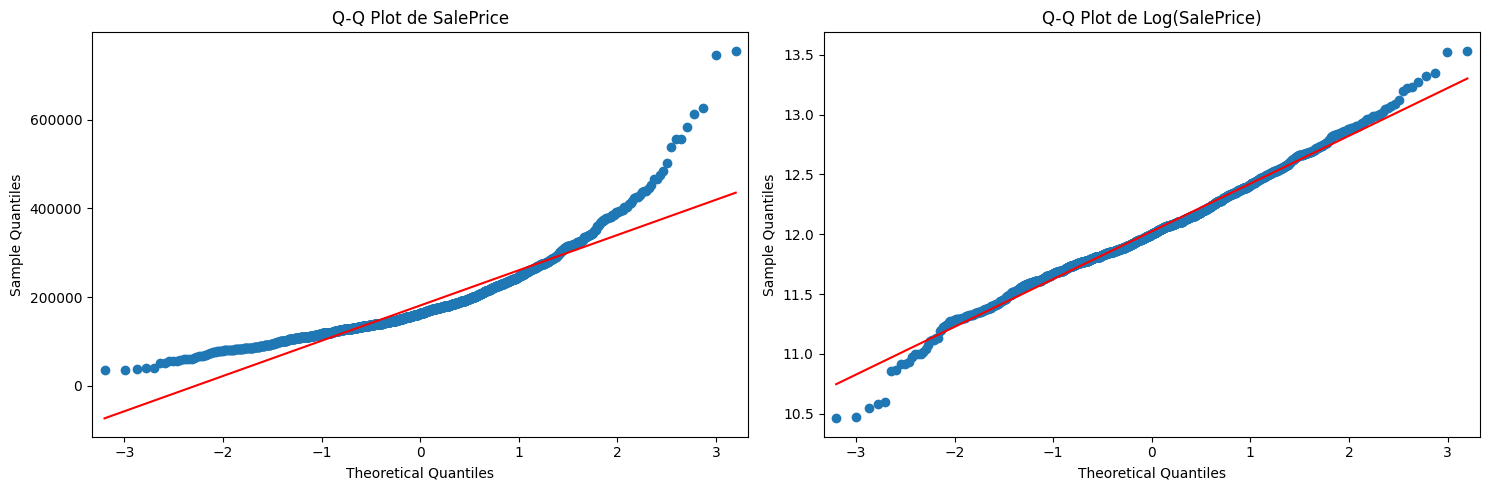

In [26]:
#Q-Q plot for SalePrice
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sm.qqplot(train['SalePrice'], line='s', ax=axes[0])
sm.qqplot(train['LogSalePrice'], line='s', ax=axes[1])
axes[0].set_title('Q-Q Plot de SalePrice')
axes[1].set_title('Q-Q Plot de Log(SalePrice)')

plt.tight_layout()
plt.show()


In [27]:
#Shapiro-Wilk test for SalePrice
shapiro_test = stats.shapiro(train['LogSalePrice'])
print(f'Shapiro-Wilk test statistic: {shapiro_test.statistic:.3f}, p-value: {shapiro_test.pvalue:.3e}')

Shapiro-Wilk test statistic: 0.991, p-value: 1.149e-07


Le résultat des QQplots et du test de shapiro (H0 distribution normale) avec W = {python} shapiro_test.statistic  avec une p-value < 0.05 confirme que la transformation de SalePrice en log donne une distribution normale. 

Valeurs nulles

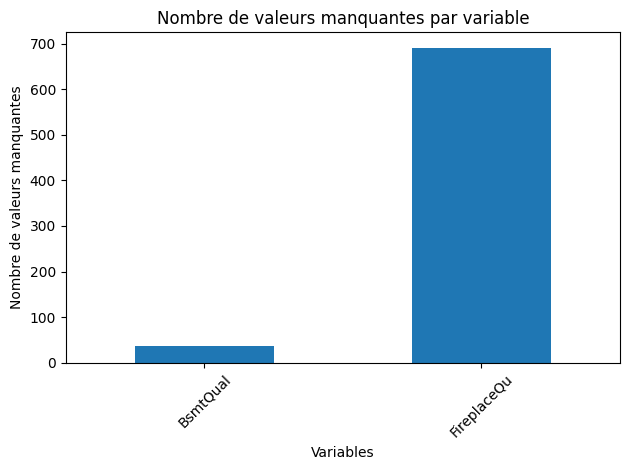

In [28]:
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_null = train[features]
missing_pd = train_null.isnull()
missing = missing_pd.sum()
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()
plt.title('Nombre de valeurs manquantes par variable')
plt.ylabel('Nombre de valeurs manquantes')
plt.xlabel('Variables')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [29]:

#sns.histplot(train_null['OverallQual'], kde=False)
train[features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OverallQual  1460 non-null   int64  
 1   ExterQual    1460 non-null   int64  
 2   BsmtQual     1423 non-null   float64
 3   KitchenQual  1460 non-null   int64  
 4   FireplaceQu  770 non-null    float64
 5   CentralAir   1460 non-null   object 
 6   LotShape     1460 non-null   int64  
 7   LandSlope    1460 non-null   int64  
 8   MoSold       1460 non-null   int64  
 9   YrSold       1460 non-null   int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 114.2+ KB


Analyse de TotalBsmtSF

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


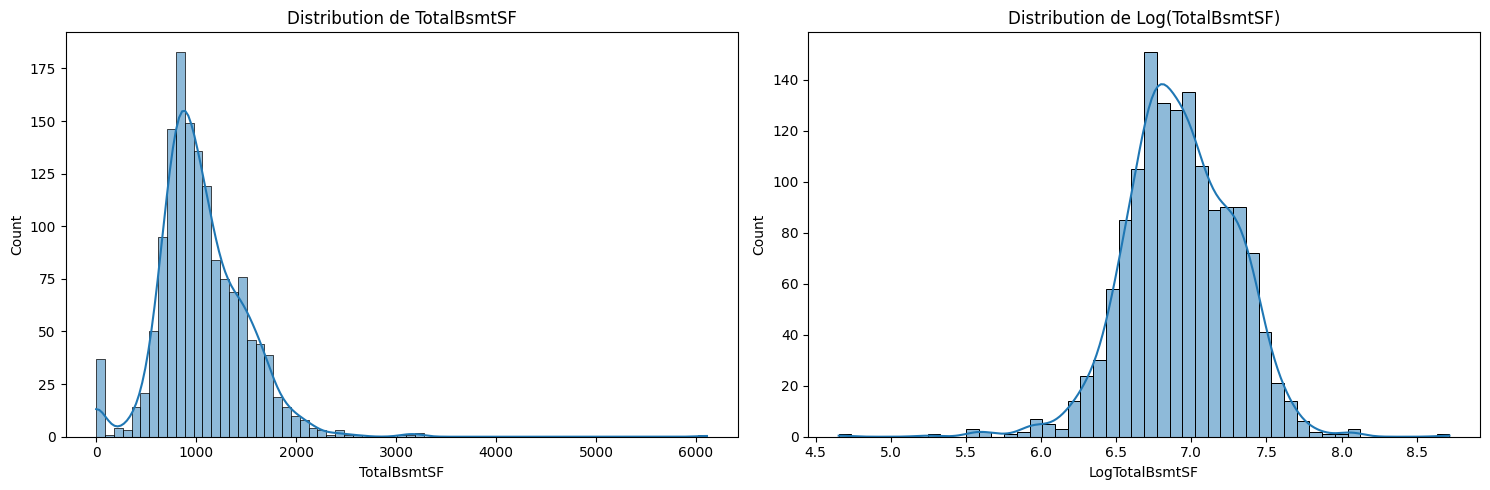

In [30]:
from scipy import stats
train['TotalBsmtSF']
train['LogTotalBsmtSF'] = np.log(train['TotalBsmtSF'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title('Distribution de TotalBsmtSF')
sns.histplot(train['TotalBsmtSF'], kde=True, ax=axes[0])
axes[1].set_title('Distribution de Log(TotalBsmtSF)')
sns.histplot(train['LogTotalBsmtSF'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

In [31]:
TotalBsmtSF_skew = train['TotalBsmtSF'].skew()
LogTotalBsmtSF_skew = train['LogTotalBsmtSF'].skew()
print(f'Skewness de TotalBsmtSF: {TotalBsmtSF_skew:.3f}')
print(f'Skewness de Log(TotalBsmtSF): {LogTotalBsmtSF_skew:.3f}')

Skewness de TotalBsmtSF: 1.524
Skewness de Log(TotalBsmtSF): nan


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


In [32]:
LogGrLivArea = np.log(train['GrLivArea'])
LogTotalBsmtSF = np.log1p(train['TotalBsmtSF'])
LogTotalBsmtSF_skew = LogTotalBsmtSF.skew()
LogGrLivArea_skew = LogGrLivArea.skew()
print(f'Skewness de Log(TotalBsmtSF): {LogTotalBsmtSF_skew:.3f}')
print(f'Skewness de Log(GrLivArea): {LogGrLivArea_skew:.3f}')

Skewness de Log(TotalBsmtSF): -5.155
Skewness de Log(GrLivArea): -0.007


Skewness de Log(TotalBsmtSF): -5.155


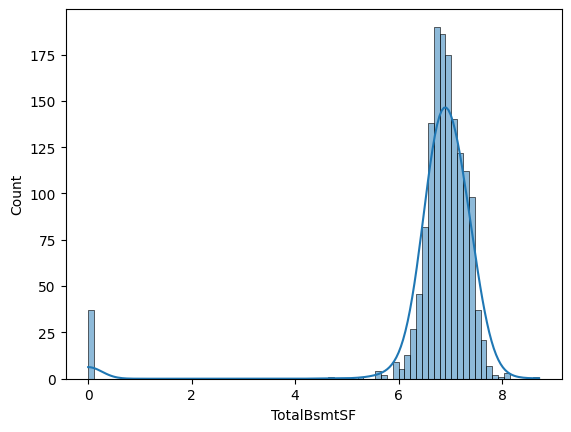

In [33]:
sns.histplot(LogTotalBsmtSF, kde=True)
LogTotalBsmtSF_skew=LogTotalBsmtSF.skew()
print(f'Skewness de Log(TotalBsmtSF): {LogTotalBsmtSF_skew:.3f}')

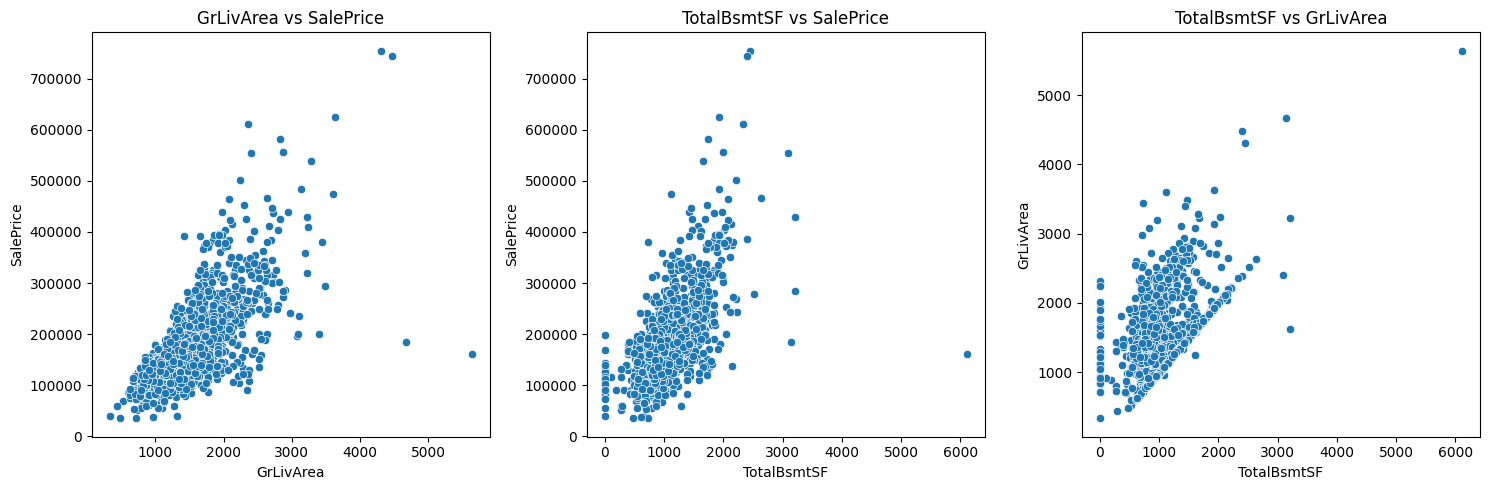

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=train, ax=axes[1])
axes[1].set_title('TotalBsmtSF vs SalePrice')
sns.scatterplot(x='TotalBsmtSF', y='GrLivArea', data=train, ax=axes[2])
axes[2].set_title('TotalBsmtSF vs GrLivArea')
plt.tight_layout()

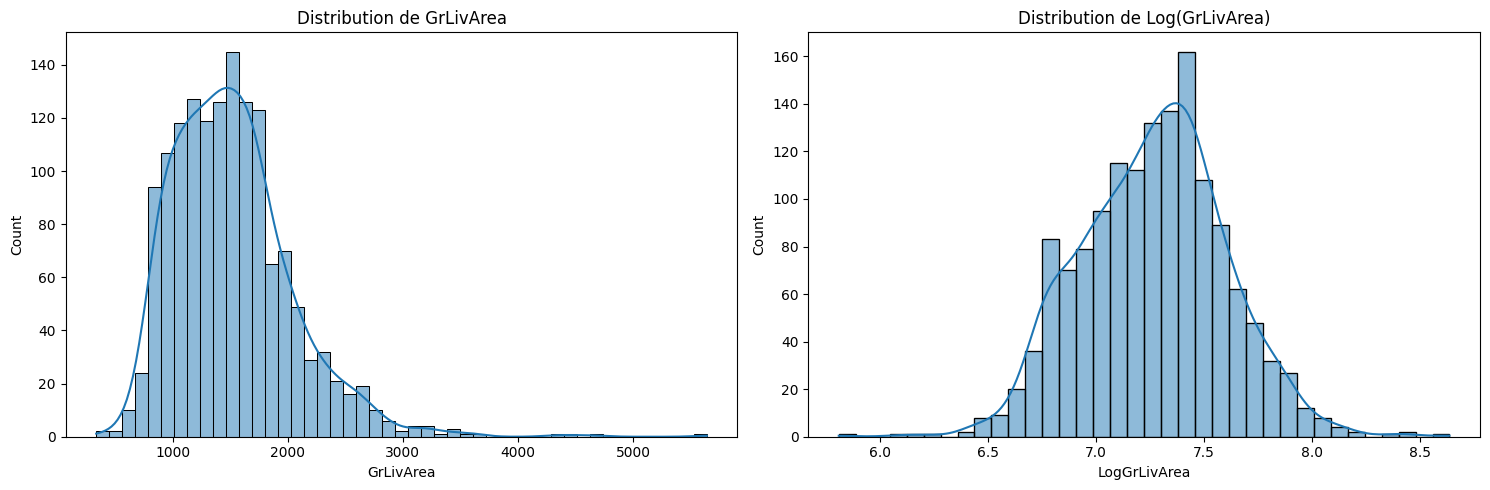

In [35]:
from scipy import stats

train['LogGrLivArea'] = np.log(train['GrLivArea'])
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].set_title('Distribution de GrLivArea')
sns.histplot(train['GrLivArea'], kde=True, ax=axes[0])
axes[1].set_title('Distribution de Log(GrLivArea)')
sns.histplot(train['LogGrLivArea'], kde=True, ax=axes[1])
plt.tight_layout()
plt.show()

In [36]:
# CI for the mean SalePrice (95%)
alpha = 0.05
mean = np.mean(train['SalePrice'])               # Mean
s = np.std(train['SalePrice'], ddof = 1)         # Standard deviation
se = s/np.sqrt(n)                                # Standard error
t_critical_value = stats.t.ppf(1-alpha/2, df=n - 1)  # (two-tailed)
low_bound = mean - t_critical_value * se         # Lower bound
up_bound = mean + t_critical_value * se          # Upper bound

print(f"Mean: {mean:,.2f}")
print(f"CI: [{low_bound:,.2f}, {up_bound:,.2f}]")

Mean: 180,921.20
CI: [176,842.84, 184,999.55]


In [37]:
# Hypothesis testing: is the mean SalePrice significantly different from $180,000?
mu0 = 180000
dof = n - 1
T = (mean - mu0) / se
p_value = 2 * (1 - stats.t.cdf(abs(T), df=dof))

print(f"T statistic: {T}")
print(f"p-value: {p_value}")

print(p_value < alpha)

T statistic: 0.44307321990459303
p-value: 0.6577784607522805
False


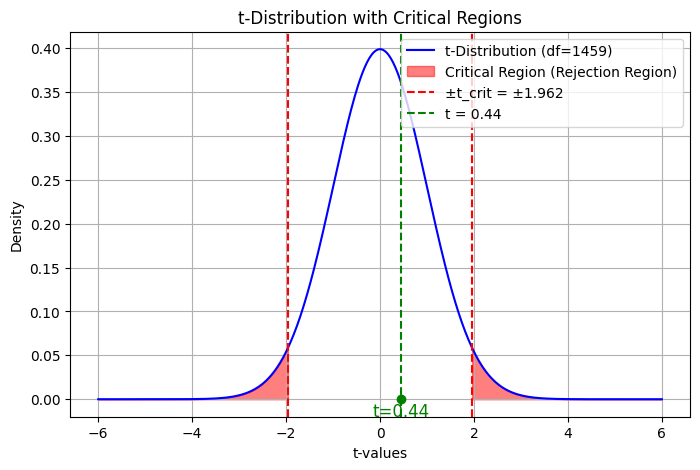

In [38]:
x = np.linspace(-6, 6, 500)
y = stats.t.pdf(x, dof)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f"t-Distribution (df={dof})", color="blue")

# critical region (two-tailed test)
x_critical_left = np.linspace(-6, -t_critical_value, 300)
x_critical_right = np.linspace(t_critical_value, 6, 300)
plt.fill_between(x_critical_left, stats.t.pdf(x_critical_left, dof), color='red', alpha=0.5, label='Critical Region (Rejection Region)')
plt.fill_between(x_critical_right, stats.t.pdf(x_critical_right, dof), color='red', alpha=0.5)

plt.axvline(-t_critical_value, color="red", linestyle="--", label=f"±t_crit = ±{t_critical_value:.3f}")
plt.axvline(t_critical_value, color="red", linestyle="--")

plt.axvline(T, color='green', linestyle='--', label=f't = {round(T,2)}')
plt.scatter([T], [0], color='green', zorder=3)  # Mark the t-value on the x-axis
plt.text(T, -0.02, f't={round(T,2)}', color='green', fontsize=12, ha='center')

plt.title('t-Distribution with Critical Regions')
plt.xlabel('t-values')
plt.ylabel('Density')
plt.legend()
plt.grid()
plt.show()

---
## Part 2: ANOVA — Finding Significant Features

Use ANOVA to determine which of the following **10 features** have a statistically significant effect on the transformed SalePrice. 

**Given features (10):**

| # | Feature | Levels | Description |
|---|---|---|---|
| 1 | `OverallQual` | 1–10 | Overall material and finish quality |
| 2 | `ExterQual` | Po, Fa, TA, Gd, Ex | Exterior material quality |
| 3 | `BsmtQual` | None, Po, Fa, TA, Gd, Ex | Basement height quality |
| 4 | `KitchenQual` | Po, Fa, TA, Gd, Ex | Kitchen quality |
| 5 | `FireplaceQu` | None, Po, Fa, TA, Gd, Ex | Fireplace quality |
| 6 | `CentralAir` | N, Y | Central air conditioning |
| 7 | `LotShape` | IR3, IR2, IR1, Reg | General shape of property |
| 8 | `LandSlope` | Sev, Mod, Gtl | Slope of property |
| 9 | `MoSold` | 1–12 | Month sold |
| 10 | `YrSold` | 2006–2010 | Year sold |

**Tasks:**
1. Extract these features into a dataframe and run **one-way ANOVA** on each
2. Identify which features are significant (p < 0.05)
3. Run a **two-way ANOVA** to test for interaction effects between pairs of significant features
4. Use **Tukey HSD** post-hoc tests where appropriate
5. Summarize: which features and interactions are significant?

ANOVA a un facteur

In [39]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
features = [
    'OverallQual', 'ExterQual', 'BsmtQual', 'KitchenQual', 'FireplaceQu', 
    'CentralAir', 'LotShape', 'LandSlope', 'MoSold', 'YrSold'
]
train_anova = train[features + ['LogSalePrice']].copy()
for col in features:
    train_anova[col] = train_anova[col].fillna('None').astype('category')
anova_results = []
for col in features:
    model = ols(f'LogSalePrice ~ C({col})', data=train_anova).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    p_value = anova_table['PR(>F)'][0]
    anova_results.append({'Feature': col, 'p-value': p_value, 'Significant': p_value < 0.05})
df_anova = pd.DataFrame(anova_results)
print(df_anova.sort_values(by='p-value'))


       Feature        p-value  Significant
0  OverallQual   0.000000e+00         True
1    ExterQual  6.935425e-195         True
2     BsmtQual  2.031282e-188         True
3  KitchenQual  4.441486e-187         True
4  FireplaceQu  6.963458e-115         True
5   CentralAir   9.855628e-44         True
6     LotShape   7.856968e-29         True
7    LandSlope   3.388375e-01        False
8       MoSold   4.496616e-01        False
9       YrSold   5.656374e-01        False


/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_49136/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_49136/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = anova_table['PR(>F)'][0]
/var/folders/3c/yjysg3qs15l4pfcxpxlc0hjc0000gn/T/ipykernel_49136/2241715068.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, u

ANOVA a deux facteurs

In [40]:
from itertools import combinations
for col1, col2 in combinations(features, 2):
    formula = f'LogSalePrice ~ C({col1}) * C({col2})'
    interaction_model = ols(formula, data=train_anova).fit()
    interaction_table = sm.stats.anova_lm(interaction_model, typ=2)
    p_value_interaction = interaction_table.iloc[2,3]
    if p_value_interaction < 0.05:
        print(f"\n---Interaction significative entre {col1} et {col2}---")
        print(f"   p-value de l'interaction: {p_value_interaction:.3e}")
        print(interaction_table)



---Interaction significative entre OverallQual et ExterQual---
   p-value de l'interaction: 5.296e-52
                                 sum_sq      df           F         PR(>F)
C(OverallQual)               204.185376     9.0  458.077839  6.178398e-294
C(ExterQual)                   0.218335     3.0    1.469465   2.210927e-01
C(OverallQual):C(ExterQual)   21.397849    27.0   16.001604   5.296425e-52
Residual                      70.922798  1432.0         NaN            NaN

---Interaction significative entre OverallQual et BsmtQual---
   p-value de l'interaction: 3.482e-82
                                  sum_sq      df             F         PR(>F)
C(OverallQual)              1.014226e+02     9.0  2.317303e+02  2.612629e-181
C(BsmtQual)                 1.999443e-10     4.0  1.027874e-09   9.999744e-01
C(OverallQual):C(BsmtQual)  3.794745e+01    36.0  2.167558e+01   3.482239e-82
Residual                    6.944446e+01  1428.0           NaN            NaN

---Interaction significative 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 21
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 


   p-value de l'interaction: 7.444e-52
                                 sum_sq      df           F        PR(>F)
C(ExterQual)                -197.814406     3.0 -972.069224  1.000000e+00
C(FireplaceQu)                34.192157     5.0  100.813113  9.725931e-76
C(ExterQual):C(FireplaceQu)   22.513638    15.0   22.126614  7.444075e-52
Residual                      97.814836  1442.0         NaN           NaN

---Interaction significative entre ExterQual et CentralAir---
   p-value de l'interaction: 3.694e-40
                                sum_sq      df           F         PR(>F)
C(ExterQual)                110.866403     3.0  469.160964  6.388929e-158
C(CentralAir)                18.837083     1.0  239.142534   4.681207e-50
C(ExterQual):C(CentralAir)   15.658527     3.0   66.263264   3.694066e-40
Residual                    114.451753  1453.0         NaN            NaN

---Interaction significative entre ExterQual et LotShape---
   p-value de l'interaction: 3.743e-59
                  

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 10
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance 


---Interaction significative entre FireplaceQu et LotShape---
   p-value de l'interaction: 3.879e-288
                                sum_sq      df            F         PR(>F)
C(FireplaceQu)              727.498746     5.0  1388.285127   0.000000e+00
C(LotShape)                  52.084289     3.0   165.653993   3.085011e-92
C(FireplaceQu):C(LotShape)  244.831788    15.0   155.737418  3.878931e-288
Residual                    150.814941  1439.0          NaN            NaN

---Interaction significative entre FireplaceQu et LandSlope---
   p-value de l'interaction: 5.437e-224
                                 sum_sq      df           F         PR(>F)
C(FireplaceQu)                99.084659     5.0  180.037692  3.029949e-125
C(LandSlope)                 201.582314     2.0  915.692075  3.078189e-156
C(FireplaceQu):C(LandSlope)  192.476936    10.0  174.866139  5.436689e-224
Residual                     159.162689  1446.0         NaN            NaN

---Interaction significative entre Central

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 8
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 55, but rank is 50
  warnings.warn('covariance of constraints does not have full '
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance

Test de Tukey


---Tukey HSD pour OverallQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.0266    1.0 -0.6358  0.689  False
     1      3   0.5387 0.0495  0.0005 1.0768   True
     1      4   0.7583 0.0002  0.2409 1.2758   True
     1      5   0.9819    0.0  0.4675 1.4962   True
     1      6   1.1685    0.0  0.6541  1.683   True
     1      7    1.423    0.0  0.9083 1.9377   True
     1      8   1.6984    0.0  1.1823 2.2145   True
     1      9   1.9945    0.0  1.4696 2.5193   True
     1     10   2.1225    0.0  1.5817 2.6633   True
     2      3   0.5121 0.0117  0.0628 0.9613   True
     2      4   0.7318    0.0  0.3075 1.1561   True
     2      5   0.9553    0.0  0.5348 1.3758   True
     2      6   1.1419    0.0  0.7213 1.5625   True
     2      7   1.3964    0.0  0.9755 1.8173   True
     2      8   1.6718    0.0  1.2492 2.0945   True
     2      9   1.9679    0.0 

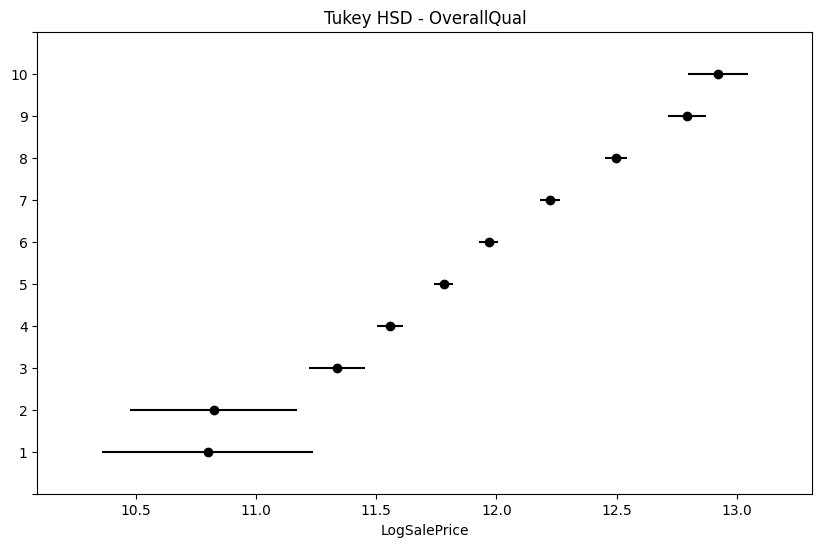


---Tukey HSD pour ExterQual---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     2      3   0.5334   0.0 0.3301 0.7368   True
     2      4   1.0067   0.0 0.8021 1.2114   True
     2      5   1.4595   0.0 1.2322 1.6868   True
     3      4   0.4733   0.0 0.4309 0.5157   True
     3      5   0.9261   0.0 0.8184 1.0337   True
     4      5   0.4528   0.0 0.3426 0.5629   True
-------------------------------------------------


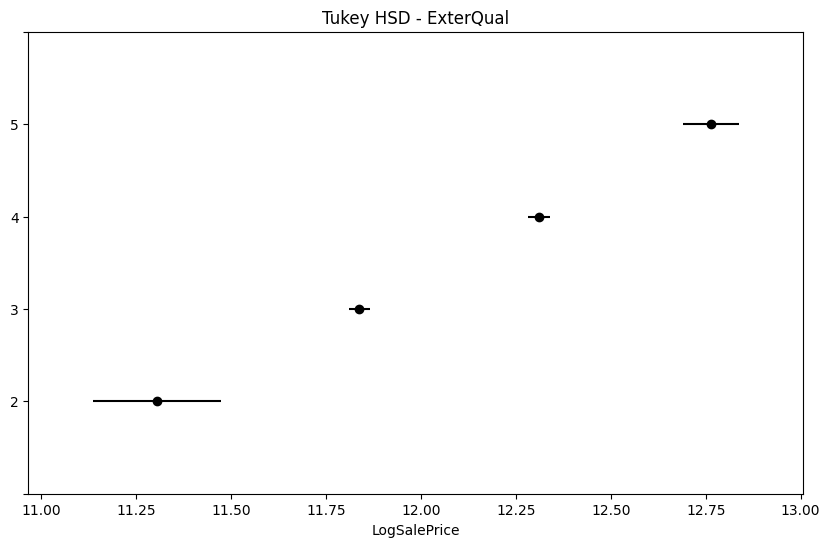

TypeError: '<' not supported between instances of 'str' and 'float'

In [41]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
for col in features:
    tukey = pairwise_tukeyhsd(endog=train_anova['LogSalePrice'], groups=train_anova[col], alpha=0.05)
    print(f"\n---Tukey HSD pour {col}---")
    print(tukey.summary())
    tukey.plot_simultaneous()
    plt.title(f'Tukey HSD - {col}')
    plt.xlabel('LogSalePrice')
    plt.show()

---
## Part 3: 2^k Factorial Design

Pick k binary (or binarized) factors from the significant features found in Part 2 and apply a factorial design analysis. For example you could binarize ordinal features into High/Low groups and study their joint effects.

**Tasks:**
- Select k factors (e.g. k=2 or k=3) and define High/Low levels
- Compute group means for all 2^k combinations
- Analyze main effects and interaction effects
- Visualize with interaction plots

In [ ]:
#Nous allons retenir les 3 features les plus significatives pour la suite de l'analyse
k = 3
# OverallQual, KitchenQual, CentralAir
df_factoriel = train[['LogSalePrice']].copy()
df_factoriel['A'] = (train['OverallQual'] >= 7).astype(int)
df_factoriel['B'] = train['KitchenQual'].isin(['Ex', 'Gd']).astype(int)
df_factoriel['C'] = (train['CentralAir'] == 'Y').astype(int)
means = df_factoriel.groupby(['A', 'B', 'C'])['LogSalePrice'].mean().reset_index()
print("Table des moyennes par combinaison de facteurs:")
print(means)
                     

Table des moyennes par combinaison de facteurs:
   A  B  C  LogSalePrice
0  0  0  0     11.442358
1  0  0  1     11.807476
2  0  1  0     11.835974
3  0  1  1     11.988174
4  1  0  0     11.808353
5  1  0  1     12.133962
6  1  1  0     12.250226
7  1  1  1     12.412245


In [ ]:
print(df_factoriel['B'])

0       1
1       0
2       1
3       1
4       1
       ..
1455    0
1456    0
1457    1
1458    1
1459    0
Name: B, Length: 1460, dtype: int64


---
## Part 4: Parametric Regression

Build a regression model using only the **significant ordinal features** identified by ANOVA (Part 2) plus the **2 numerical features**: `GrLivArea` and `TotalBsmtSF`.

**Tasks:**
- Encode ordinal features numerically (map quality levels to integers)
- Fit a linear regression model (OLS)
- Analyze the model: R², coefficient significance, residual plots
- Optionally try regularized regression (Ridge, Lasso) and compare
- Apply ANOVA on the regression model to assess factor contributions

---
## Part 5: Non-Parametric Model (Neural Network)

Build a neural network regression model using **all** available features to predict SalePrice. This is also the model that produces your `submission.csv` for Kaggle scoring.

**Tasks:**
- Preprocess all features: handle missing values, encode categoricals, scale numerics
- Build and train a neural network (e.g. `sklearn.neural_network.MLPRegressor` or PyTorch)
- Evaluate on training data (RMSE, R²) and analyze residuals
- Generate predictions for the test set and save as `submission.csv`

**Important:** The Kaggle RMSE score is evaluated on the predictions from this model.